Notebook 1 - Data Pipeline

In [1]:
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "data"


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)

START = '2005-01-01'
END   = '2025-01-01'
TICKERS = ['SPY', 'TLT', 'GLD', '^VIX']

SPY - S&P 500 ETF \
TLT - 20+ Year Treasury ETF \
GLD - Gold Futures ETF \
VIX - CBOE Volatility Index 

In [3]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
raw['Close'].to_csv(OUT / "raw" / "prices.csv")

[*********************100%***********************]  4 of 4 completed


In [4]:
raw.head()
raw.tail()
raw.shape
raw.isna().sum()

Price   Ticker
Close   GLD       0
        SPY       0
        TLT       0
        ^VIX      0
High    GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Low     GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Open    GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Volume  GLD       0
        SPY       0
        TLT       0
        ^VIX      0
dtype: int64

In [5]:
prices = raw['Close'].copy()
prices = prices.rename(columns={'^VIX': 'VIX'})
prices = prices[['SPY', 'TLT', 'GLD', 'VIX']]
prices.head()

Ticker,SPY,TLT,GLD,VIX
Date,,,,
2005-01-03,81.383720,44.396488,43.020000,14.08
2005-01-04,80.389236,43.931194,42.740002,13.98
2005-01-05,79.834541,44.166332,42.669998,14.09
2005-01-06,80.240417,44.196384,42.150002,13.58
2005-01-07,80.125435,44.296463,41.840000,13.49


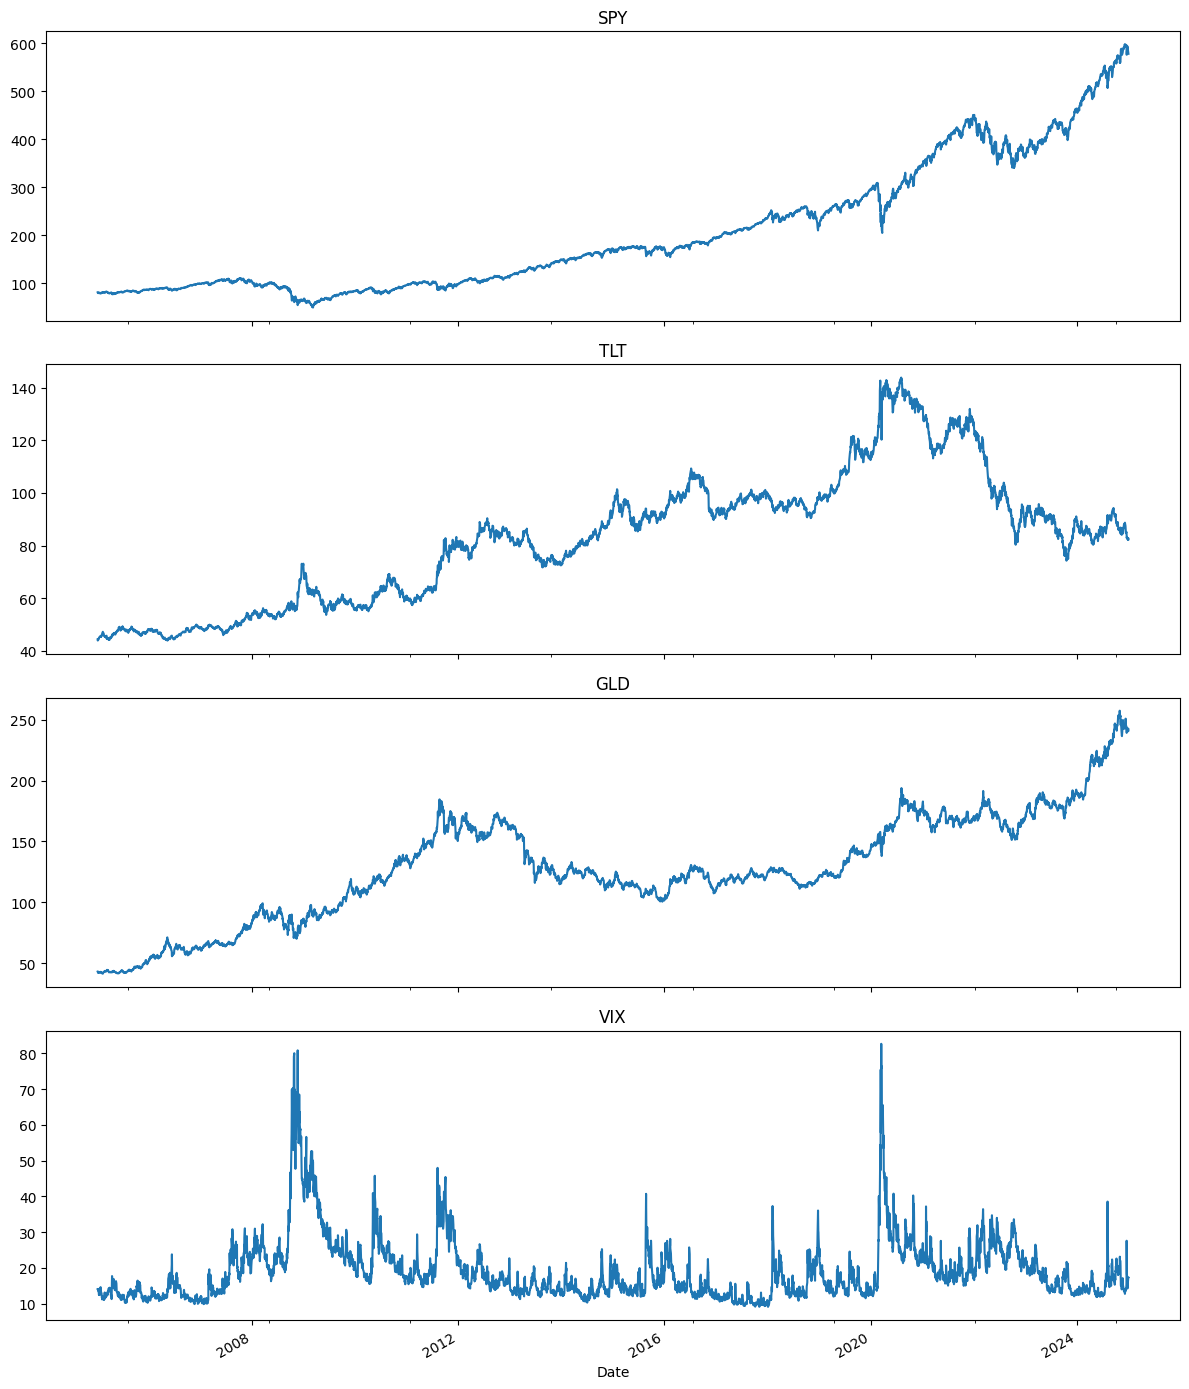

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
for axis, col in zip(axes, prices.columns):
    prices[col].plot(ax=axis, title=col)
plt.tight_layout()


In [7]:
assetprices = prices[['SPY', 'TLT', 'GLD']]

logrt = np.log(assetprices / assetprices.shift(1)) #rt = ln(Pt/Pt-1)
simplert = assetprices.pct_change() #rt = (Pt - Pt-1)/Pt-1

vix = prices['VIX'] 

In [8]:
#Removing all the NaN rows formed from dividing by 0
logrt = logrt.dropna(how='all')
simplert = simplert.dropna(how='all')

In [9]:
logrt.describe()


Ticker,SPY,TLT,GLD
count,5032.000000,5032.000000,5032.000000
mean,0.000389,0.000123,0.000343
std,0.012005,0.009320,0.011064
min,-0.115886,-0.069011,-0.091905
25%,-0.003962,-0.005420,-0.005114
50%,0.000697,0.000440,0.000547
75%,0.005787,0.005560,0.006104
max,0.135578,0.072503,0.106974


In [10]:
simplert.describe()

Ticker,SPY,TLT,GLD
count,5032.000000,5032.000000,5032.000000
mean,0.000462,0.000166,0.000405
std,0.011991,0.009323,0.011052
min,-0.109424,-0.066683,-0.087808
25%,-0.003954,-0.005405,-0.005101
50%,0.000697,0.000440,0.000547
75%,0.005803,0.005575,0.006123
max,0.145198,0.075196,0.112905


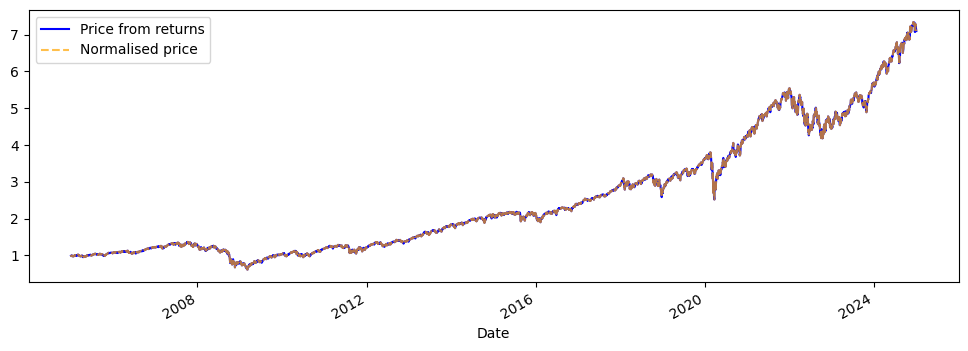

In [11]:
#Checking by recovering the prices from the simple returns

fig, axes = plt.subplots(figsize=(12, 4))

# Cumulative return starting at 1
cumret = (1 + simplert['SPY']).cumprod()
cumret.plot(ax=axes, label='Price from returns', color='blue')

# Price normalized to start at 1
normalized_price = prices['SPY'] / prices['SPY'].iloc[0]
normalized_price.plot(ax=axes, label='Normalised price', color='orange', linestyle='--', alpha=0.7)

axes.legend()
plt.show()

In [12]:
logrt.to_csv(OUT / "processed" / "logrt.csv")
simplert.to_csv(OUT / "processed" / "simplert.csv")
prices[["VIX"]].to_csv(OUT / "processed" / "vix.csv")


We now pull macro data because the price action alone has very limited signal. Two assets with the same returns could be in completely different regimes. Hence we use FRED(Federal Reserve Economic Data) to pull macroeconomic data.

In [13]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv(ROOT / ".env")
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
print('FRED connected:', fred is not None)

FRED connected: True


In [14]:
fredseries = {
    'YIELDSPREAD'  : 'T10Y2Y',
    'CPI'           : 'CPIAUCSL',
    'UNRATE'        : 'UNRATE',
    'DGS10'         : 'DGS10',
    'DGS1MO'        : 'DGS1MO',
}

rawmacro = {}
for name, code in fredseries.items():
    rawmacro[name] = fred.get_series(code, observation_start=START, observation_end=END)

macro = pd.DataFrame(rawmacro)
macro.to_csv(OUT / 'raw' / 'rawmacro.csv')
print(macro.shape)
macro.head()


(5286, 5)


,YIELDSPREAD,CPI,UNRATE,DGS10,DGS1MO
2005-01-01,NaN,191.6,5.3,NaN,NaN
2005-01-03,1.13,NaN,NaN,4.23,1.99
2005-01-04,1.09,NaN,NaN,4.29,2.05
2005-01-05,1.07,NaN,NaN,4.29,2.04
2005-01-06,1.11,NaN,NaN,4.29,2.04


YIELDSPREAD  : 10 Year Yield Spread \
CPI           : Consumer Price Index \
UNRATE        : Unemployment Rate \
DGS10         : 10 Year Treasury Yield \
DGS1MO        : 1 Month Treasury Yield 

In [15]:
tradingdays = logrt.index

# Rebuild macro with consistent datetime index
dtmacro = {}
for name, series in rawmacro.items():
    s = series.copy()
    s.index = pd.to_datetime(s.index).astype('datetime64[ns]')
    dtmacro[name] = s

macro = pd.DataFrame(dtmacro)
macro['CPIYOY'] = dtmacro['CPI'].pct_change(12) * 100
macro = macro.drop(columns=['CPI'])
macro = macro.ffill()  # fill monthly series forward before reindexing

CPIYOY : CPI Year over Year Change

In [16]:
# Reindexing the macro data to the trading days
tradingdays_ns = tradingdays.astype('datetime64[ns]')
caldays = pd.date_range(start=tradingdays_ns[0], end=tradingdays_ns[-1], freq='D')
dailymacro = macro.reindex(caldays, method='ffill').reindex(tradingdays_ns)
dailymacro.index = tradingdays

# Lag monthly series by 21 trading days (publication delay)
dailymacro['CPIYOY'] = dailymacro['CPIYOY'].shift(21)
dailymacro['UNRATE'] = dailymacro['UNRATE'].shift(21)

# Lag daily series by 1 trading day
dailymacro['DGS10']       = dailymacro['DGS10'].shift(1)
dailymacro['DGS1MO']      = dailymacro['DGS1MO'].shift(1)
dailymacro['YIELDSPREAD'] = dailymacro['YIELDSPREAD'].shift(1)

print(dailymacro.isna().sum())
dailymacro.head()

YIELDSPREAD      1
UNRATE          21
DGS10            1
DGS1MO           1
CPIYOY         272
dtype: int64


,YIELDSPREAD,UNRATE,DGS10,DGS1MO,CPIYOY
Date,,,,,
2005-01-04,NaN,NaN,NaN,NaN,NaN
2005-01-05,1.09,NaN,4.29,2.05,NaN
2005-01-06,1.07,NaN,4.29,2.04,NaN
2005-01-07,1.11,NaN,4.29,2.04,NaN
2005-01-10,1.09,NaN,4.29,2.03,NaN


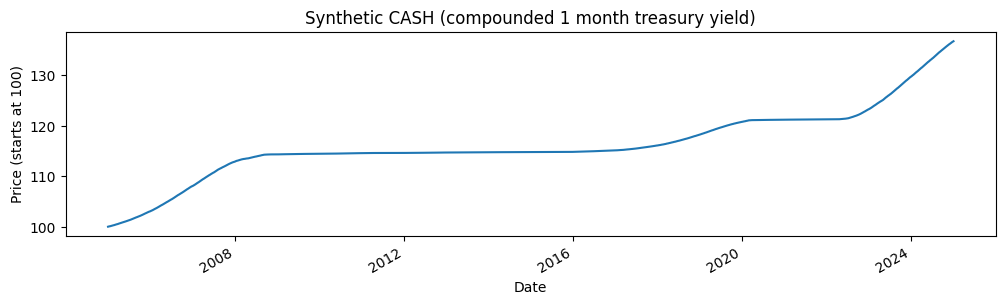

CASH total return 2005-2025: 136.8


In [17]:
dailycashreturn = (dailymacro['DGS1MO'] / 100) / 252
dailycashreturn = dailycashreturn.fillna(0)

cashprice = (1 + dailycashreturn).cumprod() * 100

cashprice.plot(title='Synthetic CASH (compounded 1 month treasury yield)', figsize=(12, 3))
plt.ylabel('Price (starts at 100)')
plt.show()

print(f'CASH total return 2005-2025: {cashprice.iloc[-1]:.1f}')

In [18]:
prices['CASH'] = cashprice
assetprices = prices[['SPY', 'TLT', 'GLD', 'CASH']]

logrt = np.log(assetprices / assetprices.shift(1)).dropna(how='all')
simplert = assetprices.pct_change().dropna(how='all')

print(logrt.shape)
logrt.describe()

(5032, 4)


Ticker,SPY,TLT,GLD,CASH
count,5032.000000,5032.000000,5032.000000,5031.000000
mean,0.000389,0.000123,0.000343,0.000062
std,0.012005,0.009320,0.011064,0.000076
min,-0.115886,-0.069011,-0.091905,0.000000
25%,-0.003962,-0.005420,-0.005114,0.000002
50%,0.000697,0.000440,0.000547,0.000011
75%,0.005787,0.005560,0.006104,0.000105
max,0.135578,0.072503,0.106974,0.000239


In [19]:
vixlag = vix.reindex(tradingdays).shift(1).to_frame('VIX')

dataset = pd.concat([logrt.add_suffix('_logret'), vixlag, dailymacro.drop(columns=['DGS1MO']),], axis=1)

dataset = dataset.dropna()

print(f'Final dataset: {dataset.shape[0]} rows')
print(f'Date range: {dataset.index[0].date()} to {dataset.index[-1].date()}')
print(f'Columns: {dataset.columns.tolist()}')
print(dataset.isna().sum())

Final dataset: 4760 rows
Date range: 2006-02-02 to 2024-12-31
Columns: ['SPY_logret', 'TLT_logret', 'GLD_logret', 'CASH_logret', 'VIX', 'YIELDSPREAD', 'UNRATE', 'DGS10', 'CPIYOY']
SPY_logret     0
TLT_logret     0
GLD_logret     0
CASH_logret    0
VIX            0
YIELDSPREAD    0
UNRATE         0
DGS10          0
CPIYOY         0
dtype: int64


This verifies that every cell in the dataset has some defined value and is not NaN.

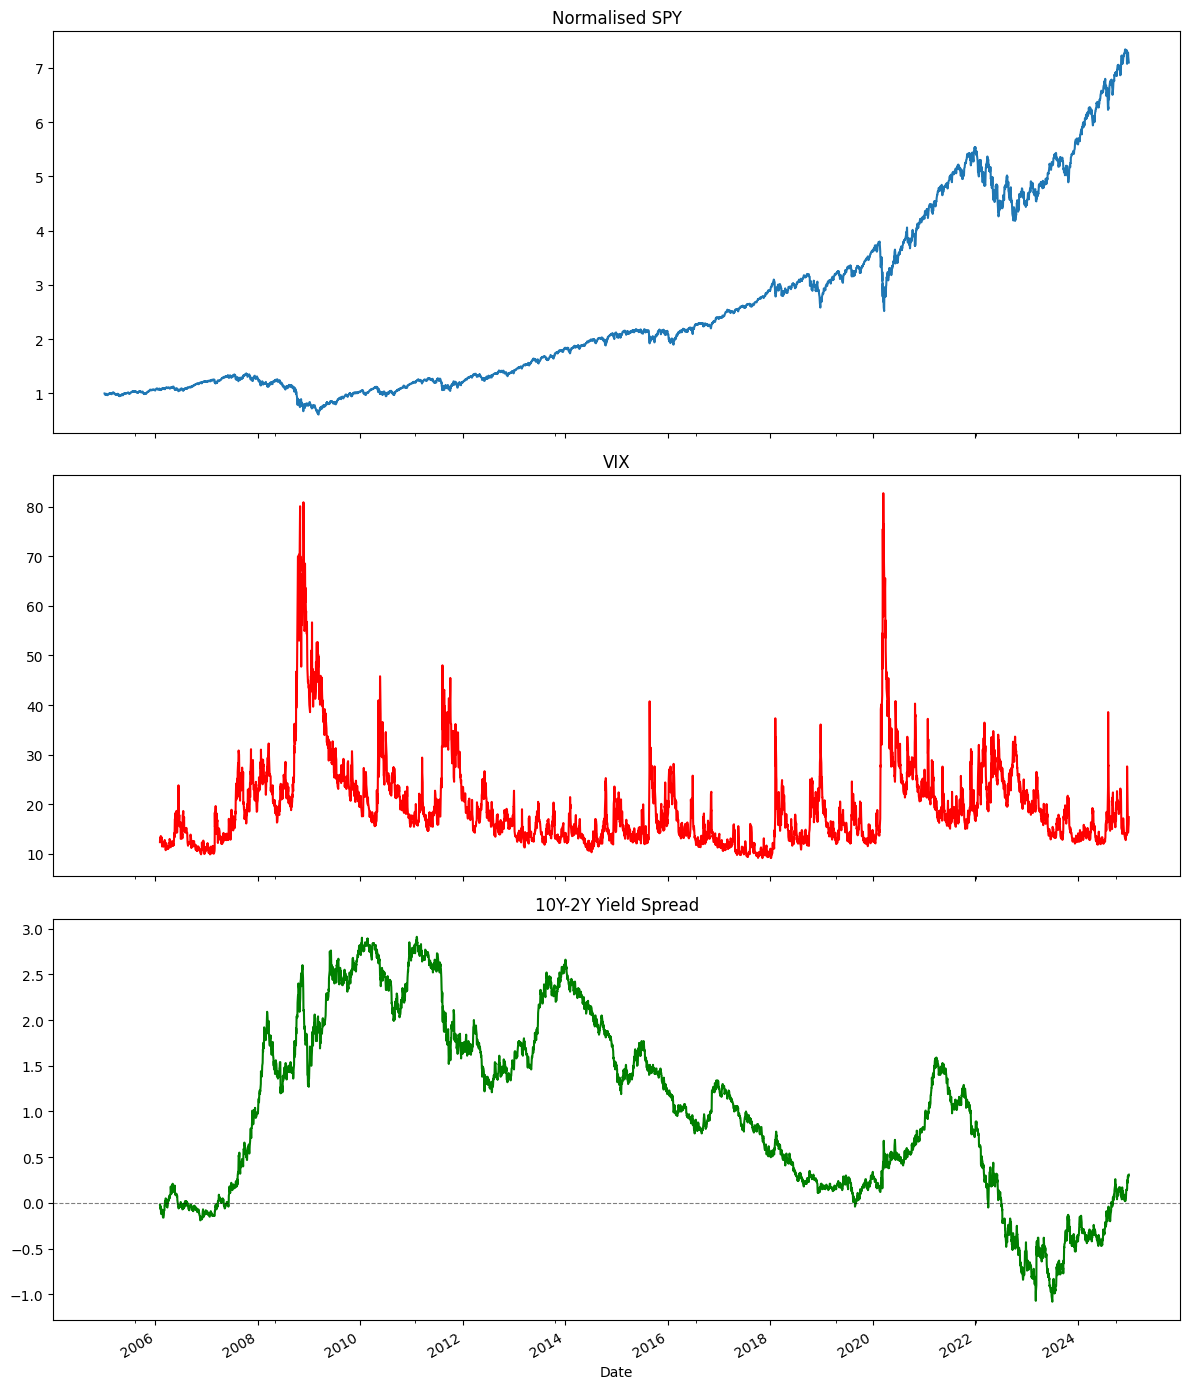

In [20]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

(prices['SPY'] / prices['SPY'].iloc[0]).plot(ax=axes[0], title='Normalised SPY')
dataset['VIX'].plot(ax=axes[1], title='VIX', color='red')
dataset['YIELDSPREAD'].plot(ax=axes[2], title='10Y-2Y Yield Spread', color='green')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=0.8)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [22]:
dataset.to_csv(OUT / 'processed' / 'dataset.csv')
logrt.to_csv(OUT / 'processed' / 'logrt.csv')
simplert.to_csv(OUT / 'processed' / 'simplert.csv')
prices[['CASH']].to_csv(OUT / 'processed' / 'cashprice.csv')